## 1. Дизайн эксперимента и предобработка данных

In [1]:
import pandas as pd


In [2]:
df1=pd.read_excel('Gen_Df.xlsx')

In [3]:
df1.head(2)

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992


In [4]:
df1.describe()

,id_order,id_client,amt_payment,dtime_pay
count,37989.000000,37401.000000,35845.000000,35560
mean,197751.747085,194078.460710,3542.546464,2022-09-15 22:58:39.975964672
min,100238.000000,178561.000000,498.000000,2022-06-03 17:48:54.432000
25%,148504.000000,186334.000000,2582.000000,2022-08-13 07:47:47.644999936
50%,197658.000000,194069.000000,3470.000000,2022-09-15 22:39:11.937999872
75%,246441.000000,201831.000000,4389.000000,2022-10-18 23:45:59.007500032
max,297607.000000,209634.000000,7633.000000,2022-12-28 22:57:20.608000
std,56733.647764,8972.581221,1426.815593,NaN


In [5]:
df1.isna().sum()

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

In [6]:
df1.isna().sum()/df1.count()


id_order       0.000000
id_client      0.015722
amt_payment    0.059813
dtime_pay      0.068307
dtype: float64

In [7]:
data=df1.dropna(subset=['id_client'])

In [8]:
data.isna().sum()

id_order          0
id_client         0
amt_payment    1556
dtime_pay      1841
dtype: int64

In [9]:
data.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468


In [10]:
df_clients=pd.read_excel('Gen_Df.xlsx', sheet_name=1)

In [11]:
df_clients.head(2)

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13


In [12]:
df_clients.isna().sum()

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

In [13]:
df_clients=df_clients.dropna()

In [15]:
df_Region_dict=pd.read_excel('Gen_Df.xlsx', sheet_name=2)

In [16]:
df_Region_dict.head(2)

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров


## 2. Расчет ключевых метрик (Конверсия и Средний чек)

In [17]:
cnt_df =df_Region_dict.groupby('city').agg(cnt_trading_point=('id_trading_point','count')).reset_index()

In [18]:
import matplotlib.pyplot as  plt 
import seaborn as sns 

C:\Users\user\AppData\Local\Temp\ipykernel_12536\425076992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_df, x='city', y='cnt_trading_point', palette='viridis')


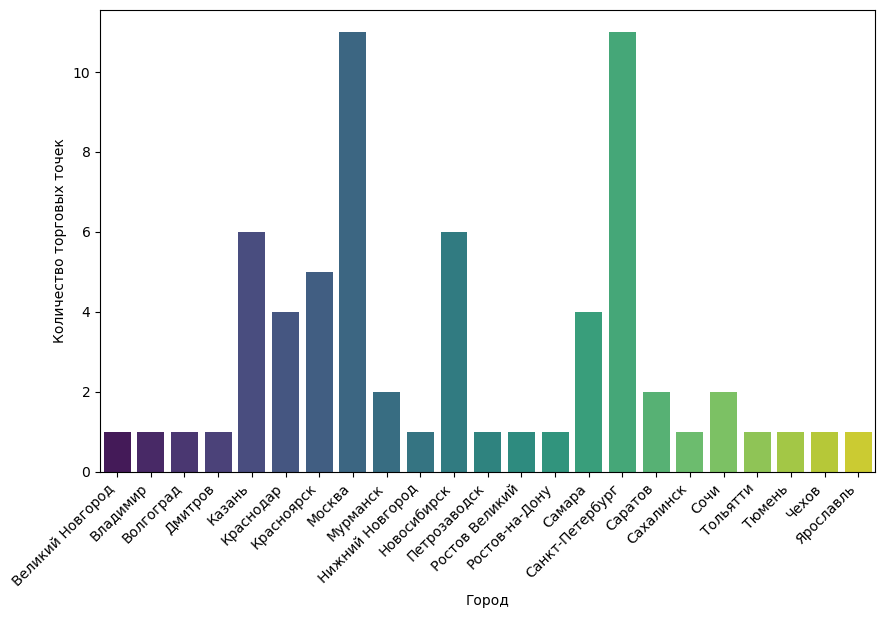

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(data=cnt_df, x='city', y='cnt_trading_point', palette='viridis')
plt.xlabel('Город', )
plt.ylabel('Количество торговых точек', )
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
len(data['id_client'].unique())


29712

In [21]:
sum_pay_per_user= data.groupby('id_client').agg(sum_pay=('amt_payment','sum')).reset_index().sort_values(by='sum_pay', ascending= False)
sum_pay_per_user.isna().sum()

id_client    0
sum_pay      0
dtype: int64

In [22]:
sum_pay_per_user.count().unique()

array([29712])

In [23]:
df2=df_clients.merge(sum_pay_per_user,on='id_client',how= 'left')

In [24]:
df2.head()

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,226069,2022-07-11 16:28:38.511,1,54,NaN
2,183981,2022-06-16 12:23:59.289,1,991,6322.0
3,322530,2022-07-08 08:56:08.714,0,1015,NaN
4,254313,2022-06-19 22:18:01.770,1,453,NaN


In [25]:
df2=df2.fillna({'sum_pay': 0})

In [26]:
df2=df2.merge(df_Region_dict,on='id_trading_point', how='left')

In [27]:
import numpy as  np

In [28]:
df2['status_purchase']=np.where(df2['sum_pay']!=0,'1','0')

In [29]:
df2.head()

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay,city,status_purchase
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар,0
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0


In [30]:
gen_df=df2 

## 3. Статистический анализ A/B теста (T-тест и Манн-Уитни)

In [31]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [32]:
def test_calc(r1,r2,alpha=0.05):
    s, p = ttest_ind(r1, r2)
    if p < alpha:
        print('Нулевая гипотеза отвергается: между средними есть значимая разница')
    else:
        print('Нулевая гипотеза принимается : между средними есть значимая разницы нет')
    return(s,p)

In [33]:
def mann_whitney_func(r1,r2,alpha=0.05):
    mw_stat, p_value = mannwhitneyu(r1,r2)
    if p_value < alpha:
        print('нулевая гипотиза отвергается,разница есть')
    else:
        print('Нулевая гипотиза принимется,разницы нет')
    return  mw_stat, p_value
    

In [34]:
df2['test_revenue'] = np.where(df2['nflag_test'] == 1, df2['sum_pay'], 0)

df2['control_revenue'] = np.where(df2['nflag_test'] == 0, df2['sum_pay'], 0)

df_agg = df2.groupby('id_trading_point')[['test_revenue', 'control_revenue']].sum().reset_index()

empty_points = []
for index, row in df_agg.iterrows():
    if row['test_revenue'] <= 0 or row['control_revenue'] <= 0:
        empty_points.append(int(row['id_trading_point']))

print(empty_points)

[1, 4, 7, 13, 23, 26, 46, 228, 603, 739, 800, 810, 866, 1015, 1099]


In [35]:

df2['is_test'] = np.where(df2['nflag_test'] == 1, 1, 0)
df2['is_control'] = np.where(df2['nflag_test'] == 0, 1, 0)
df_agg2 = df2.groupby('id_trading_point')[['is_test', 'is_control']].sum().reset_index()

#print(df_agg.head())
empty_groups = []


for index, row in df_agg2.iterrows():
    if row['is_test'] == 0 or row['is_control'] == 0:
        empty_groups.append(int(row['id_trading_point']))

print(empty_groups)

[228, 603, 739, 800, 810, 866, 1015, 1099]


### 5 Расчет общих результатов A/B-теста

In [36]:
all_empty=empty_points+empty_groups
all_empty=set(all_empty)

In [37]:
gen_df.drop(columns=['is_control','test_revenue',	'control_revenue','is_test'], inplace=True)

In [38]:
gen_df=gen_df[~gen_df['id_trading_point'].isin(all_empty)]

In [39]:
gen_df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay,city,status_purchase
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
5,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1


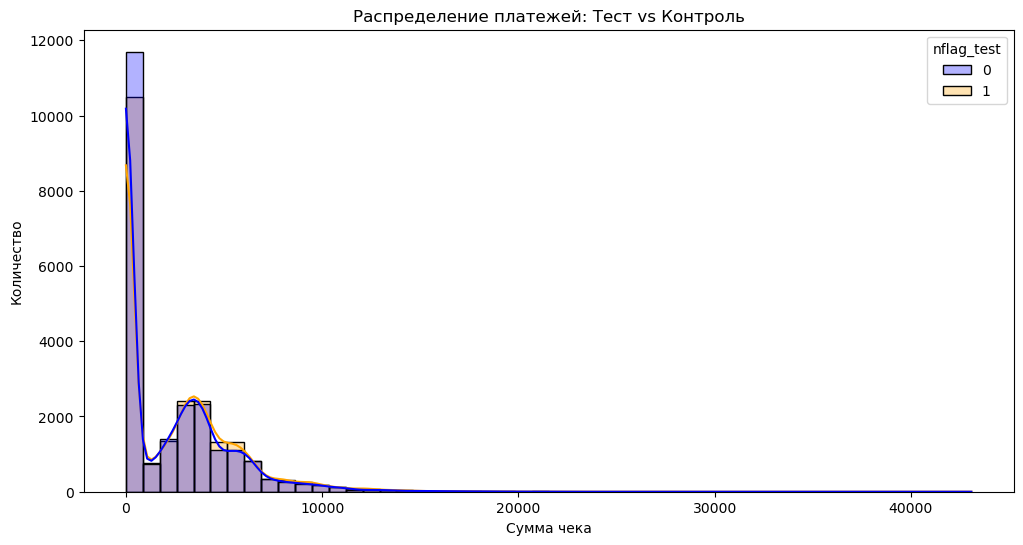

In [40]:

plt.figure(figsize=(12, 6))
sns.histplot(data=gen_df, x='sum_pay', hue='nflag_test', kde=True, bins=50, palette=['blue', 'orange'], alpha=0.3)
plt.title('Распределение платежей: Тест vs Контроль')
plt.xlabel('Сумма чека')
plt.ylabel('Количество')
plt.show()

In [41]:
test_calc(gen_df[gen_df['nflag_test']==0]['sum_pay'],gen_df[gen_df['nflag_test']==1]['sum_pay'])

Нулевая гипотеза отвергается: между средними есть значимая разница


(np.float64(-9.573285274103036), np.float64(1.0857547123769503e-21))

In [43]:
print(gen_df['status_purchase'].dtype)
print(gen_df['status_purchase'].unique())

object
['1' '0']


In [44]:
test_calc(gen_df[gen_df['nflag_test']==0]['status_purchase'].astype(float),gen_df[gen_df['nflag_test']==1]['status_purchase'].astype(float))

Нулевая гипотеза отвергается: между средними есть значимая разница


(np.float64(-9.406024876422881), np.float64(5.384854454774238e-21))

In [46]:
mann_whitney_func(gen_df[gen_df['nflag_test']==0]['sum_pay'],gen_df[gen_df['nflag_test']==1]['sum_pay'])

нулевая гипотиза отвергается,разница есть


(np.float64(243171512.5), np.float64(7.829376257720135e-25))

In [47]:
mann_whitney_func(gen_df[gen_df['nflag_test']==0]['status_purchase'].astype(float),gen_df[gen_df['nflag_test']==1]['status_purchase'].astype(float))

нулевая гипотиза отвергается,разница есть


(np.float64(245371284.5), np.float64(5.6162497735928165e-21))

##### все 2 теста показывают  что разница есть между 2 группами 


## Сегментация результатов A/B-теста

In [48]:
mann_whitney_func(gen_df[(gen_df['nflag_test']==0)&(gen_df['city']=='Москва')]['sum_pay']\
,gen_df[(gen_df['nflag_test']==1)&(gen_df['city']=='Москва')]['sum_pay'])

нулевая гипотиза отвергается,разница есть


(np.float64(17534818.5), np.float64(8.651256576787724e-17))

In [49]:
mann_whitney_func(gen_df[(gen_df['nflag_test']==0)&(gen_df['city']=='Москва')]['status_purchase'].astype(int)\
,gen_df[(gen_df['nflag_test']==1)&(gen_df['city']=='Москва')]['status_purchase'].astype(int))

нулевая гипотиза отвергается,разница есть


(np.float64(17987623.0), np.float64(1.3888194541373183e-10))

In [51]:
mann_whitney_func(gen_df[(gen_df['nflag_test']==0)&(gen_df['city']=='Санкт-Петербург')]['sum_pay']\
,gen_df[(gen_df['nflag_test']==1)&(gen_df['city']=='Санкт-Петербург')]['sum_pay'])

нулевая гипотиза отвергается,разница есть


(np.float64(8809444.5), np.float64(2.0392184217953754e-20))

In [52]:
mann_whitney_func(gen_df[(gen_df['nflag_test']==0)&(gen_df['city']=='Санкт-Петербург')]['status_purchase'].astype(int)\
,gen_df[(gen_df['nflag_test']==1)&(gen_df['city']=='Санкт-Петербург')]['status_purchase'].astype(int))

нулевая гипотиза отвергается,разница есть


(np.float64(8881151.0), np.float64(1.3118606823466691e-20))

In [54]:


all_cities = gen_df['city'].unique()
print(f"{'ГОРОД':<20} | {'P-VALUE':<10} | {'РЕЗУЛЬТАТ'}")
print("-" * 55)

for city in all_cities:

    temp_df = gen_df[gen_df['city'] == city]

    group_control = temp_df[temp_df['nflag_test'] == 0]['sum_pay']
    group_test    = temp_df[temp_df['nflag_test'] == 1]['sum_pay']

    stat, p = mannwhitneyu(group_control, group_test)
    
    if p < 0.05:
        result = "РАЗНИЦА ЕСТЬ"
    else:
        result = "Ничего нового"
    print(f"{city:<15} | {p:.5f} |   {result}")

ГОРОД                | P-VALUE    | РЕЗУЛЬТАТ
-------------------------------------------------------
Красноярск      | 0.87705 |   Ничего нового
Мурманск        | 0.54343 |   Ничего нового
Казань          | 0.37200 |   Ничего нового
Санкт-Петербург | 0.00000 |   РАЗНИЦА ЕСТЬ
Москва          | 0.00000 |   РАЗНИЦА ЕСТЬ
Саратов         | 0.78333 |   Ничего нового
Тольятти        | 0.22134 |   Ничего нового
Тюмень          | 0.03807 |   РАЗНИЦА ЕСТЬ
Волгоград       | 0.03324 |   РАЗНИЦА ЕСТЬ
Сочи            | 0.05698 |   Ничего нового
Владимир        | 0.03167 |   РАЗНИЦА ЕСТЬ
Самара          | 0.00000 |   РАЗНИЦА ЕСТЬ
Краснодар       | 0.05938 |   Ничего нового
Сахалинск       | 0.19869 |   Ничего нового
Дмитров         | 0.74226 |   Ничего нового


####  В 6 городах  есть разница между группами



## 7 этап 

In [55]:
df_result=pd.DataFrame(columns=['city','id_trading_point','count_test','count_control','count_all','avg_test','avg_control',
                               'diff','sigma_test','sigma_control','t_test_s','t_test_p'])
all_cities = gen_df['city'].unique()
for city in all_cities:
    temp_df = gen_df[gen_df['city'] == city]
    for i in temp_df['id_trading_point'].unique():
        temp_point=temp_df[temp_df['id_trading_point']==i]

        count_test=len(temp_point[temp_point['nflag_test']==1])

        count_control=len(temp_point[temp_point['nflag_test']==0])

        count_all=count_test+ count_control

        avg_test=np.mean(temp_point[temp_point['nflag_test']==1]['sum_pay'])

        avg_control=np.mean(temp_point[temp_point['nflag_test']==0]['sum_pay'])

        diff= avg_test-avg_control
        
        sigma_test=temp_point[temp_point['nflag_test']==1]['sum_pay'].std()
        
        sigma_control=temp_point[temp_point['nflag_test']==0]['sum_pay'].std()

        s,p=test_calc(temp_point[temp_point['nflag_test']==0]['sum_pay'],temp_point[temp_point['nflag_test']==1]['sum_pay'])

        new_row= pd.DataFrame({
            'city':[city],
            'id_trading_point':[i],
            'count_test':[count_test],
            'count_control':[count_control],
            'count_all':[count_all],
            'avg_test':[avg_test],
            'avg_control':[avg_control],
            'diff':[diff],
            'sigma_test':[sigma_test],
            'sigma_control':[sigma_control],
            't_test_s':[s],
            't_test_p':[p]})

        df_result=pd.concat([df_result,new_row],ignore_index=True)

        
        
    

Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Ну

C:\Users\user\AppData\Local\Temp\ipykernel_12536\2148130142.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_result=pd.concat([df_result,new_row],ignore_index=True)


Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза принимается : между средними есть значимая разницы нет
Нулевая гипотеза отвергается: между средними есть значимая разница
Нулевая гипотеза принимается : м

In [56]:
df_result.head()

,city,id_trading_point,count_test,count_control,count_all,avg_test,avg_control,diff,sigma_test,sigma_control,t_test_s,t_test_p
0,Красноярск,212,593,575,1168,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,0.483585,0.628771
1,Красноярск,278,535,489,1024,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,-1.820268,0.069011
2,Красноярск,202,551,565,1116,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,-1.155073,0.248308
3,Красноярск,444,650,562,1212,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,0.876740,0.380802
4,Красноярск,277,708,709,1417,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,0.981705,0.326413


In [57]:
df_result['label']=np.where((df_result['t_test_p']<0.05)&(df_result['diff']>0),'Позитив',
                            np.where((df_result['t_test_p']<0.05)&(df_result['diff']<0),'Негатив','Нет разницы'))
df_result['percent_count']=df_result['count_all']/df_result['count_all'].sum()

In [58]:
df_result.head(20)

,city,id_trading_point,count_test,count_control,count_all,avg_test,avg_control,diff,sigma_test,sigma_control,t_test_s,t_test_p,label,percent_count
0,Красноярск,212,593,575,1168,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,0.483585,6.287709e-01,Нет разницы,0.025773
1,Красноярск,278,535,489,1024,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,-1.820268,6.901056e-02,Нет разницы,0.022596
2,Красноярск,202,551,565,1116,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,-1.155073,2.483083e-01,Нет разницы,0.024626
3,Красноярск,444,650,562,1212,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,0.876740,3.808017e-01,Нет разницы,0.026744
4,Красноярск,277,708,709,1417,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,0.981705,3.264128e-01,Нет разницы,0.031268
5,Мурманск,54,633,640,1273,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,-0.097556,9.223005e-01,Нет разницы,0.02809
6,Мурманск,55,422,425,847,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,0.011268,9.910125e-01,Нет разницы,0.01869
7,Казань,991,270,294,564,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,-2.255258,2.450100e-02,Позитив,0.012445
8,Казань,699,482,494,976,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,0.594254,5.524804e-01,Нет разницы,0.021537
9,Казань,477,382,386,768,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,0.891593,3.728909e-01,Нет разницы,0.016947


In [59]:
df_positive=df_result[df_result['label']=='Позитив']
df_negative=df_result[df_result['label']=='Негатив']
df_no_diff=df_result[df_result['label']=='Нет разницы']

with pd.ExcelWriter('the last battle of this world.xlsx') as writer:

    df_positive.to_excel(writer, sheet_name='Positive', index=False)
    df_negative.to_excel(writer, sheet_name='Negative', index=False)
    df_no_diff.to_excel(writer, sheet_name='No_DIFF', index=False)

## 4. Итоговые выводы и бизнес-рекомендации

На основе проведенного A/B тестирования push-уведомлений получены следующие результаты:

**1. Распределение эффекта (по торговым точкам):**
* **Успех (36%):** Зафиксирован статистически значимый положительный эффект (рост среднего чека).
* **Просадка (7%):** Выявлен негативный эффект.
* **Нет разницы (57%):** Статистически значимых изменений не обнаружено (p-value > 0.05).

**2. Финансовая оценка (Unit-экономика теста):**
Прирост выручки на успешных точках (Benefit) составил **16 611 рублей.**, в то время как потенциальные потери на негативных (Lose) ограничены **1 213 рублей .** Итоговый финансовый баланс эксперимента строго положительный (+15 397 рублей .).

**3. Региональная сегментация:**
Основным драйвером роста выступили центральные регионы. Москва и Санкт-Петербург оказались абсолютными лидерами по увеличению среднего чека в тестовой группе. В региональных филиалах эффект выражен слабо.

### 🎯 Резолюция (Next Steps):
1. **Масштабирование:** Рекомендуется раскатать формат push-уведомлений на 100% аудитории в Москве и Санкт-Петербурге.
2. **Добор данных:** Для регионов внедрение пока нецелесообразно. Для 57% точек, не показавших разницы, был произведен расчет необходимого размера выборки. Рекомендуется продолжить тест в регионах до сбора расчетного количества наблюдений, чтобы преодолеть порог чувствительности (MDE = 800) и получить однозначный результат.